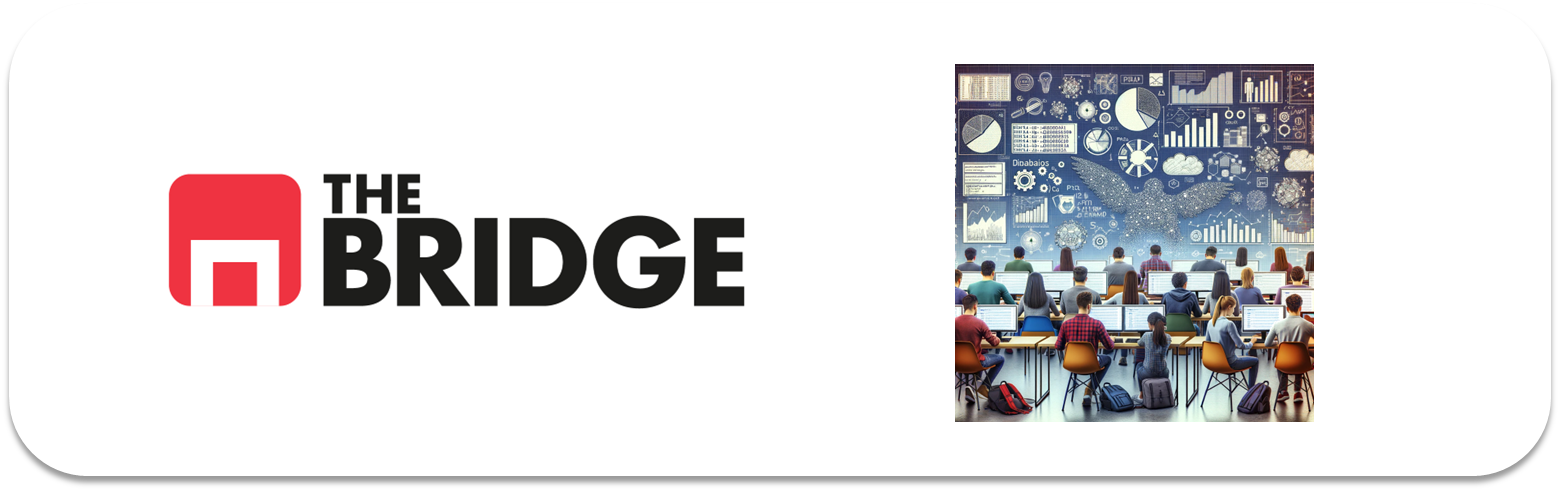

## PRACTICA OBLIGATORIA: **Clasificacion y Regresion Logistica**

* La práctica obligatoria de esta unidad consiste en modelar la supervivencia en el Titanic, por fin, además de una parte adicional multiclase. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión logística, evaluarlo contra un dataset de test reservado del original mostrando las métricas propias de los problemas de clasificación, la matriz de confusión y la curva ROC. Además se pide comparar las predicciones con los valores reales y al final adaptar el modelo a un problema multiclase.

Los pasos para guiar el trabajo:
1. Carga el dataset del Titanic. 
2. Deshazte de las variables que no vayas a usar. Limpia lo que creas necesarios pero no hagas imputaciones.
3. Escoge y analiza la variable target de forma gráfica y razona sobre el impacto de la distribución en los resultados esperados. Ten en cuenta que lo que queremos es poder predecir si un pasajero sobrevivirá.
4. Haz el split en train y test que creas conveniente pero asegurándote que ambos conjuntos tienen un reparto similar de pasajeros embarcados en las tres ciudades.
5. Construye las parejas X,y de train y test.
6. Ahora sí imputa los nulos con medias y modas en la X de train. Guarda esas medias que necesitarás en la parte de test.
7. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
8. Trata las variables para que funcionen lo mejor posible en el modelo.
9. Construye un modelo de regresión logística.
10. EXTRA: Analiza si lo crees conveniente los pesos y la importancia de las features.
11. Procesa el dataset de Test para que puedas usarlo en la evaluación 
12. Evalúa tu modelo contra el dataset de test y train. Obten las matrices de confusión y las métricas que creas adecuadas. Haz un pequeño assesment de su generabilidad.
13. EXTRA: Halla la probabilidad de supervivencia de un hombre de entre 30 y 40 años, que embarcó en Southampton en segunda clase, viajaba solo y no pagó el billete. PISTA: En este caso tendrás que calcular varias probabilidades y hacer la media de ellas.
14. EXTRA: Aprovecha todo el trabajo haciendo un único cambio en el target, ahora será la clase del viajero. Cambia el target quitándolo de X_train, X_test y añade a estos el target anterior. El resto no deberías cambiarlo. Entrena y evalua el modelo sólo con el classification_report.  



1. Carga el dataset del Titanic. 

In [2]:
df = pd.read_csv("./data/titanic.csv")
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


2. Deshazte de las variables que no vayas a usar. Limpia lo que creas necesarios pero no hagas imputaciones.

In [4]:
colum_desc = ["class", "alive", "adult_male", "embark_town", "deck", "alone"]
df = df.drop(columns=colum_desc)

3. Escoge y analiza la variable target de forma gráfica y razona sobre el impacto de la distribución en los resultados esperados. Ten en cuenta que lo que queremos es poder predecir si un pasajero sobrevivirá.

In [5]:
target = ["survived"]

print(df["survived"].value_counts())
print(df["survived"].value_counts(normalize=True).round(3) * 100)


survived
0    549
1    342
Name: count, dtype: int64
survived
0    61.6
1    38.4
Name: proportion, dtype: float64


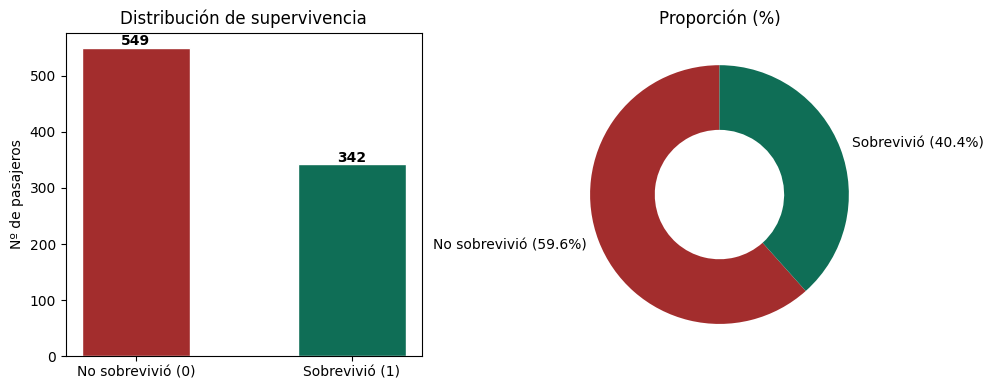

In [6]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['survived'].value_counts()
axes[0].bar(['No sobrevivió (0)', 'Sobrevivió (1)'], counts.values,
            color=['#A32D2D', '#0F6E56'], edgecolor='white', width=0.5)
axes[0].set_title('Distribución de supervivencia')
axes[0].set_ylabel('Nº de pasajeros')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

pcts = df['survived'].value_counts(normalize=True) * 100
axes[1].pie(pcts.values, labels=['No sobrevivió (59.6%)', 'Sobrevivió (40.4%)'],
            colors=['#A32D2D', '#0F6E56'], startangle=90,
            wedgeprops=dict(width=0.5))
axes[1].set_title('Proporción (%)')

plt.tight_layout()
plt.show()


El dataset presenta un desbalance moderado(60/40), no extremo pero si relevante.

Esto implica que un clasificador que prediga siempre "no sobrevivió" alcanzaría un accuracy del 59,6 % sin aprender nada, con lo que será necesario comprementarlo con precision, recall y F1-score.

4. Haz el split en train y test que creas conveniente pero asegurándote que ambos conjuntos tienen un reparto similar de pasajeros embarcados en las tres ciudades.

In [7]:
# Split 80/20 estratificado por embarked
df = df.dropna(subset=['embarked'])
train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df["embarked"])

print(f"Train: {len(train)} | Test: {len(test)}")
print()
print("Train embarked:")
print(train['embarked'].value_counts(normalize=True).round(4) * 100)
print()
print("Test embarked:")
print(test['embarked'].value_counts(normalize=True).round(4) * 100)

Train: 711 | Test: 178

Train embarked:
embarked
S    72.43
C    18.85
Q     8.72
Name: proportion, dtype: float64

Test embarked:
embarked
S    72.47
C    19.10
Q     8.43
Name: proportion, dtype: float64


5. Construye las parejas X,y de train y test.

In [8]:
X_train = train.drop(columns="survived")
y_train = train[target]

X_test = test.drop(columns="survived")
y_test = test[target]

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape} | y_test:  {y_test.shape}")

X_train: (711, 8) | y_train: (711, 1)
X_test:  (178, 8) | y_test:  (178, 1)


6. Ahora sí imputa los nulos con medias y modas en la X de train. Guarda esas medias que necesitarás en la parte de test.

In [9]:
valor = X_train["age"].mean()

X_train = X_train.fillna(valor)
X_test = X_test.fillna(valor)

print(f"Nulos X_train: {X_train.isnull().sum().sum()}")
print(f"Nulos X_test:  {X_test.isnull().sum().sum()}")

Nulos X_train: 0
Nulos X_test:  0


7. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.

Antes de empezar con el EDA voy a pasar las categóricas a numéricas para poder incluirlas en la matriz de correlación, ya que en ambos casos pasarían a ser binarias.

In [10]:
# LabelEncoder para sex (binaria)
le = LabelEncoder()
X_train["sex"] = le.fit_transform(X_train["sex"])
X_test["sex"] = le.transform(X_test["sex"])

# OneHotEncoding para embarked y who
X_train = pd.get_dummies(X_train, columns=["embarked", "who"], drop_first=False)
X_test = pd.get_dummies(X_test, columns=["embarked", "who"],drop_first=False)

In [11]:
print(X_train.head())
print(X_train.columns.tolist())

     pclass  sex        age  sibsp  parch    fare  embarked_C  embarked_Q  \
46        3    1  29.710454      1      0  15.500       False        True   
230       1    0  35.000000      1      0  83.475       False       False   
657       3    0  32.000000      1      1  15.500       False        True   
888       3    0  29.710454      1      2  23.450       False       False   
809       1    0  33.000000      1      0  53.100       False       False   

     embarked_S  who_child  who_man  who_woman  
46        False      False     True      False  
230        True      False    False       True  
657       False      False    False       True  
888        True      False    False       True  
809        True      False    False       True  
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_C', 'embarked_Q', 'embarked_S', 'who_child', 'who_man', 'who_woman']


**Matriz de correlación**

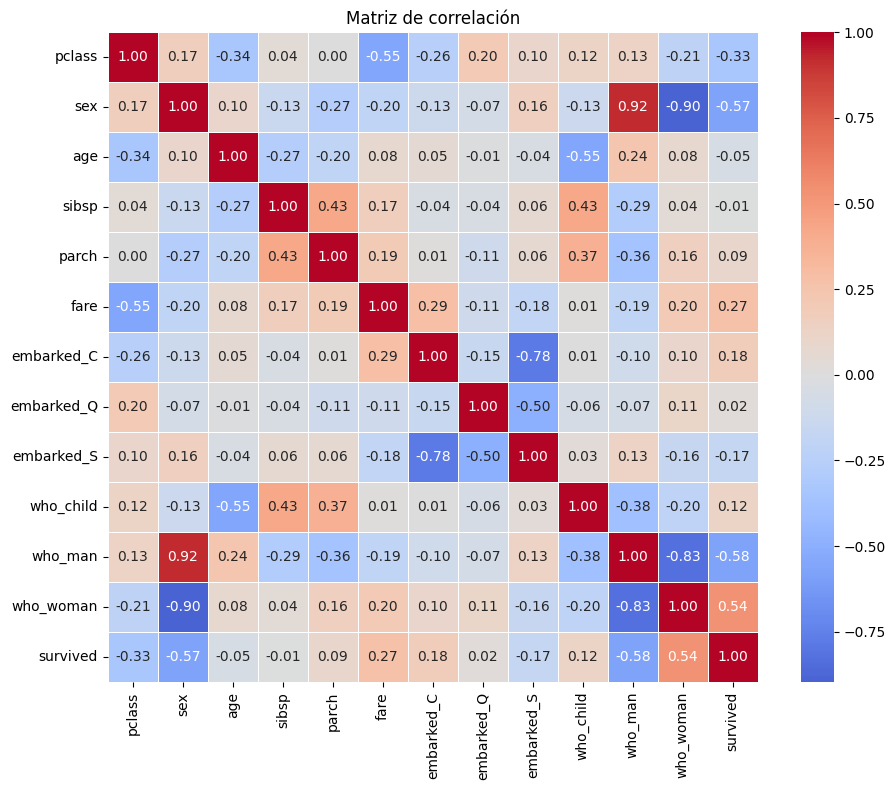

In [12]:
eda = X_train.copy()
eda["survived"] = y_train.values

corr = eda.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

**Features selecionadas:**
* **pclass:** correlación moderada-alta con survived(-0.33). Refleja el estatus socioeconómico del pasajero, que tuvo un impacto directo en el acceso a los botes salvavidas.
* **fare:** correlación moderada con survived(0.269). Complementa a pclass aportando una medida continua del estatus económico.
* **who_man, who_woman, who_child:** las variables más informativas. who_woman(0.54), who_man(0.58).

    Prefiero who sobre sex porque captura además la categoría niño, y porque sex presenta un multicolienalidad severa con who(>0.9)
* **embarked_S y embarked_C:** tienen una correlación moderada con survived (-1.17 y 0.18), que aporta información adicional más allá de la clase
* **age:** correlación casi nula(-0.047), pero incluyo esta variable para poder predecir en función de la edad.

**Features eliminadas:**
* **sex:** multicolienalidad muy alta con who(>0.9), información ya capturada.
* **embarked_Q:** correlación muy baja(0.02)
* **sibsp:** correlación casi nula (-0.007)
* **parch:** correlación baja(0.09).

In [13]:
features = ["pclass", "fare", "who_man", "who_woman", "who_child", "age", "embarked_S", "embarked_C"]

X_train = X_train[features]
X_test = X_test[features]

print(X_train.shape)
print(X_test.shape)

(711, 8)
(178, 8)


8. Trata las variables para que funcionen lo mejor posible en el modelo.

In [14]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(X_train_scaled.describe().round(3))


        pclass     fare  who_man  who_woman  who_child      age  embarked_S  \
count  711.000  711.000  711.000    711.000    711.000  711.000     711.000   
mean     0.000   -0.000    0.000     -0.000     -0.000    0.000       0.000   
std      1.001    1.001    1.001      1.001      1.001    1.001       1.001   
min     -1.622   -0.618   -1.248     -0.663     -0.306   -2.228      -1.621   
25%     -0.412   -0.464   -1.248     -0.663     -0.306   -0.592      -1.621   
50%      0.798   -0.345    0.801     -0.663     -0.306    0.000       0.617   
75%      0.798   -0.027    0.801      1.509     -0.306    0.406       0.617   
max      0.798    9.393    0.801      1.509      3.264    3.858       0.617   

       embarked_C  
count     711.000  
mean       -0.000  
std         1.001  
min        -0.482  
25%        -0.482  
50%        -0.482  
75%        -0.482  
max         2.075  


9. Construye un modelo de regresión logística.

In [15]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


10. EXTRA: Analiza si lo crees conveniente los pesos y la importancia de las features.

In [16]:
coeficientes = pd.Series(model.coef_[0], index=X_train_scaled.columns).sort_values()

print(coeficientes.round(3))

pclass       -0.820
who_man      -0.721
embarked_S   -0.223
age          -0.173
embarked_C    0.019
fare          0.046
who_child     0.182
who_woman     0.653
dtype: float64


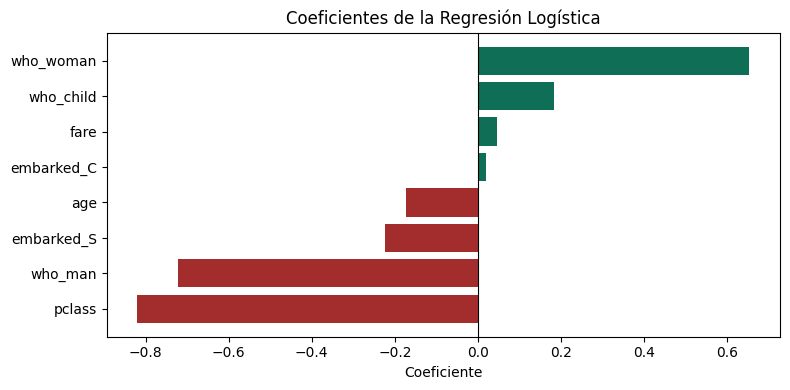

In [17]:
colors = ['#A32D2D' if c < 0 else '#0F6E56' for c in coeficientes.values]

plt.figure(figsize=(8, 4))
plt.barh(coeficientes.index, coeficientes.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes de la Regresión Logística')
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.show()

**pclass** y **who_man** son las features con más peso en negativo y **who_woman** la de más peso en positivo

11. Procesa el dataset de Test para que puedas usarlo en la evaluación 

Esto ya lo he hecho, todos los cambios aplicados a Train ya se los apliqué a Test.

12. Evalúa tu modelo contra el dataset de test y train. Obten las matrices de confusión y las métricas que creas adecuadas. Haz un pequeño assesment de su generabilidad.

Accuracy train: 0.810
Accuracy test:  0.770

Matriz de confusión - Train:
[[382  58]
 [ 77 194]]

Matriz de confusión - Test:
[[85 24]
 [17 52]]


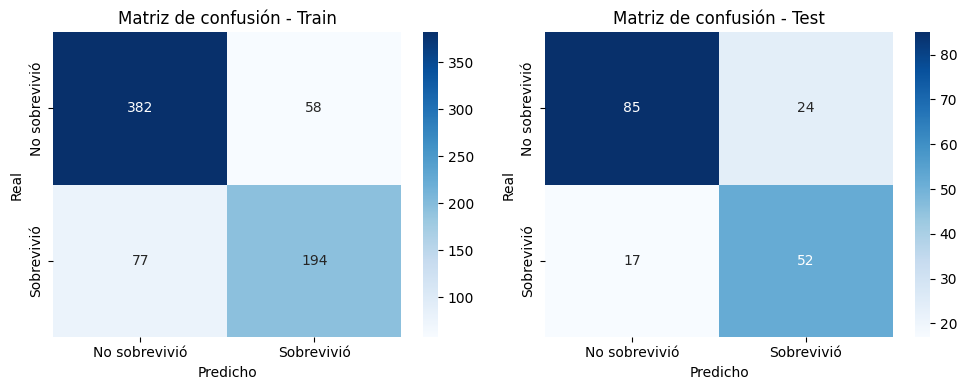


Classification Report - Train:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       440
           1       0.77      0.72      0.74       271

    accuracy                           0.81       711
   macro avg       0.80      0.79      0.80       711
weighted avg       0.81      0.81      0.81       711


Classification Report - Test:
              precision    recall  f1-score   support

           0       0.83      0.78      0.81       109
           1       0.68      0.75      0.72        69

    accuracy                           0.77       178
   macro avg       0.76      0.77      0.76       178
weighted avg       0.78      0.77      0.77       178



In [18]:
# Predicciones
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# Accuracy
print(f"Accuracy train: {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Accuracy test:  {accuracy_score(y_test,  y_pred_test):.3f}")

# Matrices de confusión
print("\nMatriz de confusión - Train:")
print(confusion_matrix(y_train, y_pred_train))

print("\nMatriz de confusión - Test:")
print(confusion_matrix(y_test, y_pred_test))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train, y_test],
    [y_pred_train, y_pred_test],
    ['Train', 'Test']
):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No sobrevivió', 'Sobrevivió'],
                yticklabels=['No sobrevivió', 'Sobrevivió'])
    ax.set_title(f'Matriz de confusión - {title}')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')

plt.tight_layout()
plt.show()

# Métricas completas
print("\nClassification Report - Train:")
print(classification_report(y_train, y_pred_train))

print("\nClassification Report - Test:")
print(classification_report(y_test, y_pred_test))


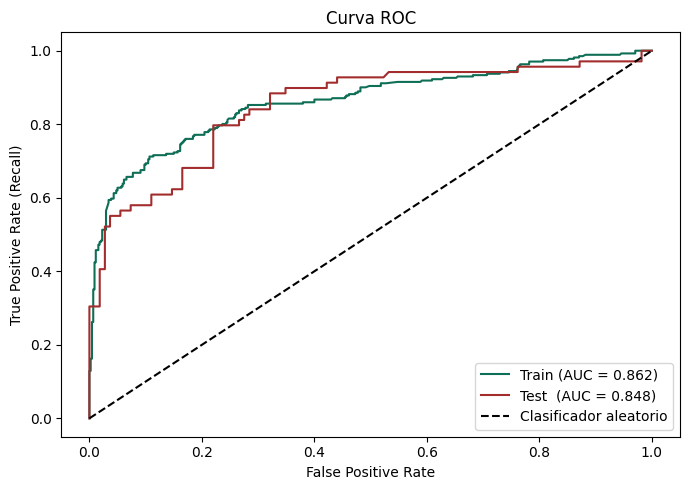

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilidades
y_prob_train = model.predict_proba(X_train_scaled)[:, 1]
y_prob_test  = model.predict_proba(X_test_scaled)[:, 1]

# Curvas ROC
fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_prob_test)

auc_train = roc_auc_score(y_train, y_prob_train)
auc_test  = roc_auc_score(y_test,  y_prob_test)

# Gráfico
plt.figure(figsize=(7, 5))
plt.plot(fpr_train, tpr_train, label=f'Train (AUC = {auc_train:.3f})', color='#0F6E56')
plt.plot(fpr_test,  tpr_test,  label=f'Test  (AUC = {auc_test:.3f})',  color='#A32D2D')
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curva ROC')
plt.legend()
plt.tight_layout()
plt.show()

## Assessment de Generalización

El modelo alcanza un accuracy de 0.810 en train y 0.770 en test, con una caída de 4 puntos
que indica un **ligero overfitting controlado**.

### Capacidad discriminativa:

La curva ROC refuerza la buena generalización del modelo:
- **AUC Train: 0.862 / AUC Test: 0.848** → ambas curvas muy por encima del clasificador 
aleatorio (AUC = 0.5)
- La diferencia de solo **1.4 puntos** entre train y test en el AUC confirma que el modelo 
no está memorizando el train sino aprendiendo patrones generales
- Un AUC de 0.848 en test se considera **bueno** (>0.8), el modelo distingue correctamente 
entre supervivientes y no supervivientes en el 84.8% de los casos independientemente 
del umbral de clasificación

### El modelo generaliza bien por las siguientes razones:

- La caída entre train y test es **consistente y proporcional** en todas las métricas,
sin anomalías que sugieran memorización del train
- Los errores en test están **equilibrados** (24 FP vs 17 FN), sin sesgo sistemático 
hacia ninguna clase
- Un weighted avg F1 de 0.77 en test es **un buen resultado para un modelo lineal** 
con solo 8 features

13. EXTRA: Halla la probabilidad de supervivencia de un hombre de entre 30 y 40 años, que embarcó en Southampton en segunda clase, viajaba solo y no pagó el billete. PISTA: En este caso tendrás que calcular varias probabilidades y hacer la media de ellas.

In [20]:
print(X_train.columns.tolist())

['pclass', 'fare', 'who_man', 'who_woman', 'who_child', 'age', 'embarked_S', 'embarked_C']


In [25]:
# Creamos un DataFrame con 11 filas, una por cada edad entre 30 y 40
pasajeros = pd.DataFrame({
    'pclass':      [2] * 11,        # 2ª clase, repetido 11 veces
    'fare':        [0] * 11,        # no pagó billete, repetido 11 veces       
    'who_man':     [True] * 11,     # es un hombre, repetido 11 veces
    'who_woman':   [False] * 11,    # no es mujer, repetido 11 veces
    'who_child':   [False] * 11,    # no es niño, repetido 11 veces
    'age':         list(range(30, 41)), # edades de 30 a 40 inclusive
    'embarked_S':  [True] * 11,     # embarcó en Southampton, repetido 11 veces
    'embarked_C':  [False] * 11,    # no embarcó en Cherbourg, repetido 11 veces
})

# Aplicamos el scaler ajustado en train para poner los datos en la misma escala que el modelo espera
pasajeros_scaled = pd.DataFrame(scaler.transform(pasajeros), columns=pasajeros.columns)

# predict_proba devuelve dos columnas: prob clase 0 y prob clase 1
# con [:, 1] nos quedamos solo con la probabilidad de sobrevivir
probs = model.predict_proba(pasajeros_scaled)[:, 1]

# Añadimos las probabilidades como columna al DataFrame original para verlas junto a la edad
pasajeros['probabilidad'] = probs

# Mostramos solo age y probabilidad
print(pasajeros[['age', 'probabilidad']])

# Calculamos la media de las 11 probabilidades
print(f"\nMedia de probabilidad de supervivencia: {probs.mean() * 100:.3f} %")

    age  probabilidad
0    30      0.168761
1    31      0.166906
2    32      0.165067
3    33      0.163244
4    34      0.161438
5    35      0.159647
6    36      0.157873
7    37      0.156115
8    38      0.154373
9    39      0.152647
10   40      0.150937

Media de probabilidad de supervivencia: 15.973 %


14. EXTRA: Aprovecha todo el trabajo haciendo un único cambio en el target, ahora será la clase del viajero. Cambia el target quitándolo de X_train, X_test y añade a estos el target anterior. El resto no deberías cambiarlo. Entrena y evalua el modelo sólo con el classification_report.

In [26]:
# Nuevo target: pclass
y_train_multi = X_train['pclass']
y_test_multi  = X_test['pclass']

# Quitamos pclass de X y añadimos survived
X_train_multi = X_train.drop(columns='pclass')
X_train_multi['survived'] = y_train.values

X_test_multi = X_test.drop(columns='pclass')
X_test_multi['survived'] = y_test.values

# Reescalamos
scaler_multi = StandardScaler()
X_train_multi_scaled = pd.DataFrame(scaler_multi.fit_transform(X_train_multi), columns=X_train_multi.columns)
X_test_multi_scaled  = pd.DataFrame(scaler_multi.transform(X_test_multi),      columns=X_test_multi.columns)

# Entrenamos
model_multi = LogisticRegression(random_state=42, max_iter=1000)
model_multi.fit(X_train_multi_scaled, y_train_multi)

# Evaluamos
from sklearn.metrics import classification_report
print("Classification Report - Train:")
print(classification_report(y_train_multi, model_multi.predict(X_train_multi_scaled)))
print("Classification Report - Test:")
print(classification_report(y_test_multi,  model_multi.predict(X_test_multi_scaled)))

Classification Report - Train:
              precision    recall  f1-score   support

           1       0.85      0.85      0.85       163
           2       0.60      0.25      0.35       143
           3       0.78      0.94      0.85       405

    accuracy                           0.78       711
   macro avg       0.74      0.68      0.68       711
weighted avg       0.76      0.78      0.75       711

Classification Report - Test:
              precision    recall  f1-score   support

           1       0.85      0.78      0.82        51
           2       0.50      0.22      0.31        41
           3       0.68      0.90      0.77        86

    accuracy                           0.71       178
   macro avg       0.68      0.63      0.63       178
weighted avg       0.69      0.71      0.68       178



## Assessment del Modelo Multiclase

El modelo alcanza un accuracy de 0.78 en train y 0.71 en test, con una caída de 7 puntos
que indica un **ligero overfitting controlado**.

### Comportamiento por clase:

**Clase 1 (1ª clase):**
* F1 de 0.85 en train y 0.82 en test: el modelo la identifica muy bien y generaliza 
correctamente. Es la clase más diferenciada por su perfil socioeconómico alto.

**Clase 3 (3ª clase):**
* F1 de 0.85 en train y 0.77 en test: buen resultado. El recall muy alto 
(0.94 train / 0.90 test) indica que el modelo detecta bien a los pasajeros de 3ª clase,
aunque a costa de algunos falsos positivos.

**Clase 2 (2ª clase):**
* F1 de 0.35 en train y 0.31 en test: el modelo tiene grandes dificultades para 
identificarla. El recall muy bajo (0.25 train / 0.22 test) significa que solo detecta 
1 de cada 4 pasajeros de 2ª clase.